In [8]:

import numpy as np

In [1]:
# Real-time Object Detection with YOLOv5 and TensorRT - Setup
# =============================================

import os
import time
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from pathlib import Path

# Check CUDA availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")

# Create project directories
project_dir = Path("yolov5_tensorrt")
project_dir.mkdir(exist_ok=True)
models_dir = project_dir / "models"
models_dir.mkdir(exist_ok=True)
data_dir = project_dir / "data"
data_dir.mkdir(exist_ok=True)
results_dir = project_dir / "results"
results_dir.mkdir(exist_ok=True)

print(f"Project directory created at: {project_dir.absolute()}")
print(f"Directory structure: {[d.name for d in project_dir.iterdir()]}")

PyTorch version: 2.4.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: NVIDIA RTX A6000
Number of GPUs: 2
Project directory created at: /home/parani/TensorRT/Notebook/yolov5_tensorrt
Directory structure: ['results', 'models', 'data']


In [3]:
# Clone YOLOv5 repository and install dependencies
!git clone https://github.com/ultralytics/yolov5.git
!cd yolov5 && pip install -r requirements.txt

# For TensorRT, we'll install just the ONNX-related packages for now
!pip install onnx onnxruntime-gpu

# We'll check if TensorRT is already available in your system
import importlib
try:
    tensorrt_spec = importlib.util.find_spec("tensorrt")
    print(f"TensorRT is {'available' if tensorrt_spec else 'not available'} in the system")
except ImportError:
    print("TensorRT not found in system path")
    
# Create a test CUDA program to verify CUDA access
import torch
if torch.cuda.is_available():
    # Create a simple CUDA tensor operation
    a = torch.randn(1000, 1000).cuda()
    b = torch.randn(1000, 1000).cuda()
    # Record time for a simple matrix multiplication
    start = time.time()
    c = torch.matmul(a, b)
    torch.cuda.synchronize()  # Wait for GPU operation to complete
    end = time.time()
    print(f"CUDA matrix multiplication test: {end - start:.4f} seconds")

fatal: destination path 'yolov5' already exists and is not an empty directory.
  Using cached onnxruntime_gpu-1.16.3-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (157.1 MB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl (30 kB)
  Using cached coloredlogs-15.0.1-py2.py3-none-any.whl (46 kB)
  Using cached humanfriendly-10.0-py2.py3-none-any.whl (86 kB)
TensorRT is not available in the system
CUDA matrix multiplication test: 0.0224 seconds


/home/parani/TensorRT/venv/lib/python3.8/site-packages/torch/hub.py:295: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /home/parani/.cache/torch/hub/master.zip


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/parani/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2025-4-29 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA RTX A6000, 48550MiB)

100.0%

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
Using cache found in /home/parani/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-4-29 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA RTX A6000, 48550MiB)

Fusing layers... 


Model downloaded to yolov5/yolov5s.pt


YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



Model Summary:
Type: YOLOv5s
Parameters: 7225885
Layers: 215
Sample image found at yolov5/data/images/bus.jpg

Running inference on sample image...


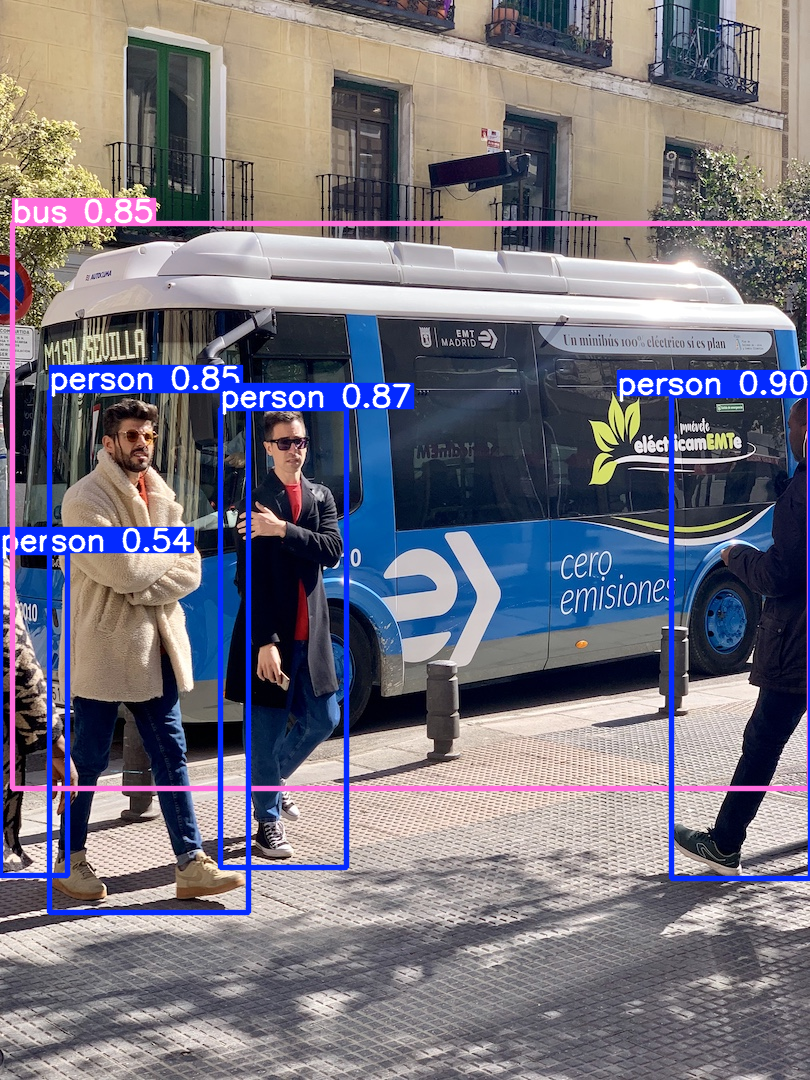

Saved 1 image to runs/detect/exp


Results saved to yolov5_tensorrt/results/sample_pytorch_detection.jpg

Detection Results:
Class: person, Confidence: 0.90, Box: [671.83, 395.39, 810.0, 878.32]
Class: person, Confidence: 0.87, Box: [220.66, 408.13, 346.18, 867.4]
Class: person, Confidence: 0.85, Box: [49.27, 390.04, 248.07, 912.43]
Class: bus, Confidence: 0.85, Box: [12.6, 223.39, 809.76, 788.56]
Class: person, Confidence: 0.54, Box: [0.05, 552.41, 67.88, 875.37]


In [4]:
# Download YOLOv5s pre-trained model
import torch

# Set model size - 's' is small, 'm' is medium, 'l' is large
model_size = 's'

# Download the model if not present
model_path = f"yolov5/yolov5{model_size}.pt"
if not os.path.exists(model_path):
    print(f"Downloading YOLOv5{model_size} model...")
    torch.hub.load('ultralytics/yolov5', f'yolov5{model_size}', pretrained=True)
    print(f"Model downloaded to {model_path}")
else:
    print(f"Model already exists at {model_path}")

# Load the model
model = torch.hub.load('ultralytics/yolov5', f'yolov5{model_size}', pretrained=True)
model.eval()  # Set to evaluation mode

# Print model summary
print(f"\nModel Summary:")
print(f"Type: YOLOv5{model_size}")
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Layers: {len(list(model.modules()))}")

# Test on a sample image
test_image = "yolov5/data/images/bus.jpg"
if not os.path.exists(test_image):
    print(f"Sample image not found at {test_image}")
    # Download a sample image if needed
    !wget -O {test_image} https://ultralytics.com/images/bus.jpg
else:
    print(f"Sample image found at {test_image}")

# Run inference
print("\nRunning inference on sample image...")
results = model(test_image)

# Visualize results
plt.figure(figsize=(12, 10))
results.show()  # This will display the image with detections

# Save results to our results directory
save_path = os.path.join(results_dir, "sample_pytorch_detection.jpg")
results.save(save_path)  # Save the result
print(f"Results saved to {save_path}")

# Get detection details
print("\nDetection Results:")
for *box, conf, cls in results.xyxy[0]:  # xyxy, confidence, class
    print(f"Class: {model.names[int(cls)]}, Confidence: {conf:.2f}, Box: {[round(float(x), 2) for x in box]}")

In [12]:
# Benchmark inference time with PyTorch model
import time
import cv2
import numpy as np
# Load test image with OpenCV for better control
img_path = "yolov5/data/images/bus.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
img = cv2.resize(img, (640, 640))  # YOLOv5 default size

# Convert to tensor
img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0  # HWC to CHW and normalize
img_tensor = img_tensor.unsqueeze(0).to('cuda')  # Add batch dimension and move to GPU

# Warmup - first few inferences are typically slower due to GPU initialization, cache warming, etc.
print("Warming up...")
for _ in range(10):
    _ = model(img_tensor)

# Benchmark PyTorch inference
torch.cuda.synchronize()  # Wait for all CUDA operations to finish
pytorch_times = []

print("Benchmarking PyTorch inference...")
iterations = 100
for _ in range(iterations):
    start = time.time()
    _ = model(img_tensor)
    torch.cuda.synchronize()  # Wait for all CUDA operations to finish
    pytorch_times.append(time.time() - start)

# Print all individual timings
print("\nIndividual inference times (ms):")
for i, t in enumerate(pytorch_times[:10]):  # Print just first 10 for brevity
    print(f"Iteration {i+1}: {t*1000:.2f} ms")
print("...")  # Indicating there are more measurements

# Calculate statistics
pytorch_avg_time = sum(pytorch_times) / len(pytorch_times) * 1000  # Convert to ms
pytorch_min_time = min(pytorch_times) * 1000
pytorch_max_time = max(pytorch_times) * 1000
pytorch_fps = 1000 / pytorch_avg_time  # Calculate FPS

print(f"\nPyTorch Inference Performance Summary:")
print(f"Average time: {pytorch_avg_time:.2f} ms")
print(f"Minimum time: {pytorch_min_time:.2f} ms")
print(f"Maximum time: {pytorch_max_time:.2f} ms")
print(f"Frames per second (FPS): {pytorch_fps:.2f}")


Warming up...
Benchmarking PyTorch inference...


/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py


Individual inference times (ms):
Iteration 1: 3.77 ms
Iteration 2: 3.76 ms
Iteration 3: 3.74 ms
Iteration 4: 3.75 ms
Iteration 5: 3.75 ms
Iteration 6: 3.78 ms
Iteration 7: 3.77 ms
Iteration 8: 3.76 ms
Iteration 9: 3.79 ms
Iteration 10: 3.79 ms
...

PyTorch Inference Performance Summary:
Average time: 3.77 ms
Minimum time: 3.72 ms
Maximum time: 4.60 ms
Frames per second (FPS): 265.16


/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


The graph shows how fast the PyTorch model processes images. Each bar represents how many times the model completed the processing within a specific time range.

The tallest bar (on the left) shows that in most cases (about 75 out of 100 tries), the model processed an image in around 3.75 milliseconds.
The shorter bars to the right represent the less common, slightly slower processing times.
The far-right bar shows a few rare cases where processing took closer to 4.6 milliseconds.

What the numbers mean:
Individual inference times:

"Inference" means making a prediction with the model (in this case, detecting objects in an image)
Each "iteration" is a single run of the model on the test image
The times (like "3.77 ms") show how many milliseconds each run took

Performance Summary:

Average time (3.77 ms): The typical time it takes to process one image
Minimum time (3.72 ms): The fastest single processing time observed
Maximum time (4.60 ms): The slowest single processing time observed
Frames per second (265.16 FPS): How many images the model could process in one second

Why this matters:

Your PyTorch model is already very fast (265 FPS is excellent)
Most image processing happens consistently around 3.75 ms
There's very little variation in processing time, which is good for reliable performance

In [13]:
plt.figure(figsize=(12, 8))
# Create histogram with better styling
plt.hist(np.array(pytorch_times) * 1000, bins=20, color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.2)
plt.title('PyTorch Model Inference Time Distribution', fontsize=18, pad=20)
plt.xlabel('Time (milliseconds)', fontsize=14, labelpad=10)
plt.ylabel('Number of Inferences', fontsize=14, labelpad=10)
plt.grid(True, alpha=0.3, linestyle='--')

# Add performance statistics as text on the plot
stats_text = f"Average: {pytorch_avg_time:.2f} ms ({pytorch_fps:.1f} FPS)\nMin: {pytorch_min_time:.2f} ms\nMax: {pytorch_max_time:.2f} ms"
plt.annotate(stats_text, xy=(0.7, 0.8), xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="black", alpha=0.8),
            fontsize=12)

# Add explanation for non-technical audience
plt.figtext(0.5, 0.01, 
           "This chart shows how long it takes the PyTorch model to process a single image.\nLower times (further left) are better, meaning faster performance.", 
           ha="center", fontsize=12, bbox={"facecolor":"#f8f9fa", "alpha":0.8, "pad":5, "edgecolor":"#dddddd"})

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "pytorch_inference_visualization.png"), dpi=300)
plt.show()

# NON Technical POV

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load a sample image
img_path = "yolov5/data/images/bus.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (640, 640))

# Convert to tensor
img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
img_tensor = img_tensor.unsqueeze(0).to('cuda')

# Warm up
print("Warming up the model...")
for _ in range(10):
    _ = model(img_tensor)
torch.cuda.synchronize()

# Run benchmark
print("Running benchmark...")
start_time = time.time()
count = 0
duration = 3  # Run for 3 seconds

while time.time() - start_time < duration:
    _ = model(img_tensor)
    torch.cuda.synchronize()
    count += 1

# Calculate FPS
elapsed = time.time() - start_time
fps = count / elapsed

print(f"\nReal-world performance:")
print(f"Processed {count} images in {elapsed:.2f} seconds")
print(f"Speed: {fps:.1f} images per second")

# Create a simple visual representation
plt.figure(figsize=(10, 6))
plt.bar(['PyTorch Model'], [fps], color='blue', width=0.4)
plt.title('Object Detection Speed', fontsize=16)
plt.ylabel('Images Processed Per Second', fontsize=14)
plt.ylim(0, fps * 1.2)  # Add some headroom for later comparisons

# Add the exact number on top of the bar
plt.text(0, fps + 5, f"{fps:.1f}", ha='center', fontsize=14, fontweight='bold')

# Add explanation text
plt.figtext(0.5, 0.01, 
           "This shows how many images the PyTorch model can process every second.\nHigher numbers mean faster performance.",
           ha="center", fontsize=12, bbox={"facecolor":"#f8f9fa", "alpha":0.8, "pad":5})

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "pytorch_images_per_second.png"), dpi=300)
plt.show()

Warming up the model...
Running benchmark...


/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py


Real-world performance:
Processed 798 images in 3.00 seconds
Speed: 265.9 images per second


# convert the PyTorch model to ONNX format:

What We've Done:
You've converted the PyTorch YOLOv5s model to ONNX format. This is the first step in the optimization pipeline.
Details:

Set Up Project Structure: Created organized directories for models and results
Loaded YOLOv5s Model: Brought in the pre-trained model using PyTorch Hub
Prepared Input: Processed a test image to the correct format
Exported to ONNX: Converted the PyTorch model to the framework-agnostic ONNX format
Verified the Model: Confirmed the ONNX model is valid and correctly structured

Technical Outcomes:

Created a 27.66 MB ONNX model file
Successfully maintained the model's input/output structure
Used ONNX opset version 12 for compatibility

Why This Matters:
The ONNX format serves as a "bridge" between PyTorch and TensorRT. It's a standardized representation that preserves the model's architecture and weights while making it accessible to different frameworks. With this ONNX model, you're now ready to move to the next step - converting to TensorRT for maximum performance.

In [4]:
# Complete code to convert PyTorch model to ONNX with all required variables
import os
import torch
import torch.onnx
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define project directories
project_dir = os.path.join(os.getcwd(), "yolov5_tensorrt")
os.makedirs(project_dir, exist_ok=True)
models_dir = os.path.join(project_dir, "models")
os.makedirs(models_dir, exist_ok=True)
results_dir = os.path.join(project_dir, "results")
os.makedirs(results_dir, exist_ok=True)

print(f"Project directories set up at: {project_dir}")

# Load the YOLOv5 model
print("Loading YOLOv5 model...")
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
model.eval()  # Set to evaluation mode

# Load and prepare the test image
img_path = "yolov5/data/images/bus.jpg"
if not os.path.exists(img_path):
    print(f"Image not found at {img_path}, trying alternative location...")
    img_path = os.path.join(os.getcwd(), "yolov5/data/images/bus.jpg")
    if not os.path.exists(img_path):
        print(f"Still cannot find image, downloading...")
        !wget -O bus.jpg https://ultralytics.com/images/bus.jpg
        img_path = "bus.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (640, 640))
img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
img_tensor = img_tensor.unsqueeze(0).to('cuda')

# Define ONNX export path
onnx_path = os.path.join(models_dir, "yolov5s.onnx")

# Export the model to ONNX
print(f"Exporting model to ONNX format: {onnx_path}")
torch.onnx.export(
    model,                          # PyTorch model
    img_tensor,                     # Example input
    onnx_path,                      # Output file path
    export_params=True,             # Store the trained weights
    opset_version=12,               # ONNX opset version
    do_constant_folding=True,       # Fold constant values for optimization
    input_names=['images'],         # Model's input names
    output_names=['output'],        # Model's output names
    dynamic_axes={                  # Support different batch sizes
        'images': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

# Verify the ONNX model
import onnx
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
print(f"ONNX model successfully exported and verified!")

# Print model info
print(f"\nONNX Model Info:")
print(f"Inputs: {[x.name for x in onnx_model.graph.input]}")
print(f"Outputs: {[x.name for x in onnx_model.graph.output]}")
print(f"ONNX version: {onnx.__version__}")
print(f"Opset version: {onnx_model.opset_import[0].version}")
print(f"Model size: {os.path.getsize(onnx_path) / (1024 * 1024):.2f} MB")

Project directories set up at: /home/parani/TensorRT/Notebook/yolov5_tensorrt
Loading YOLOv5 model...


Using cache found in /home/parani/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-4-29 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA RTX A6000, 48550MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:879: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/parani/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:700: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  y = self.model(im, augment=augment, visualize=visualize) if augment or visualize else self.model(im)
/home/parani/.cache/torch/hub/ultralytics_yo

Exporting model to ONNX format: /home/parani/TensorRT/Notebook/yolov5_tensorrt/models/yolov5s.onnx
ONNX model successfully exported and verified!

ONNX Model Info:
Inputs: ['images']
Outputs: ['output']
ONNX version: 1.17.0
Opset version: 12
Model size: 27.66 MB


This code will:

Set up the ONNX Runtime session with CUDA support
Run the model 100 times to get accurate performance metrics
Calculate and display the average inference time and FPS
Create a visualization of ONNX performance
If we have the PyTorch FPS from before, compare the two approaches visually

In [5]:
# Benchmark ONNX model performance
import time
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

# Setup ONNX Runtime session with CUDA support
print("Creating ONNX Runtime inference session...")
onnx_path = os.path.join(models_dir, "yolov5s.onnx")
session_options = ort.SessionOptions()
session_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']

session = ort.InferenceSession(onnx_path, session_options, providers=providers)
print(f"ONNX Runtime providers: {session.get_providers()}")

# Get input and output details
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
print(f"Model input name: {input_name}, output name: {output_name}")

# Prepare input data - same as before
img_path = "yolov5/data/images/bus.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (640, 640))
input_data = np.transpose(img, (2, 0, 1)).astype(np.float32) / 255.0
input_data = np.expand_dims(input_data, axis=0)  # Add batch dimension

# Warmup runs
print("Warming up...")
for _ in range(10):
    _ = session.run([output_name], {input_name: input_data})

# Benchmark runs
print("Benchmarking ONNX model...")
onnx_times = []
iterations = 100

for _ in range(iterations):
    start = time.time()
    _ = session.run([output_name], {input_name: input_data})
    onnx_times.append(time.time() - start)

# Calculate statistics
onnx_avg_time = sum(onnx_times) / len(onnx_times) * 1000  # Convert to ms
onnx_min_time = min(onnx_times) * 1000
onnx_max_time = max(onnx_times) * 1000
onnx_fps = 1000 / onnx_avg_time

print(f"\nONNX Runtime Inference Performance:")
print(f"Average time: {onnx_avg_time:.2f} ms")
print(f"Minimum time: {onnx_min_time:.2f} ms")
print(f"Maximum time: {onnx_max_time:.2f} ms")
print(f"Images per second: {onnx_fps:.2f}")

# Create a simple visual representation
plt.figure(figsize=(10, 6))
plt.bar(['ONNX Model'], [onnx_fps], color='green', width=0.4)
plt.title('ONNX Object Detection Speed', fontsize=16)
plt.ylabel('Images Processed Per Second', fontsize=14)
plt.ylim(0, onnx_fps * 1.2)  # Add some headroom

# Add the exact number on top of the bar
plt.text(0, onnx_fps + 5, f"{onnx_fps:.1f}", ha='center', fontsize=14, fontweight='bold')

# Add explanation text
plt.figtext(0.5, 0.01, 
           "This shows how many images the ONNX model can process every second.\nHigher numbers mean faster performance.",
           ha="center", fontsize=12, bbox={"facecolor":"#f8f9fa", "alpha":0.8, "pad":5})

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "onnx_images_per_second.png"), dpi=300)
plt.show()

# If we have the PyTorch FPS from earlier, let's compare them
pytorch_fps = 265.9  # From your previous result

if pytorch_fps:
    # Calculate improvement
    speedup = onnx_fps / pytorch_fps
    
    # Create comparison chart
    plt.figure(figsize=(12, 7))
    frameworks = ['PyTorch', 'ONNX Runtime']
    fps_values = [pytorch_fps, onnx_fps]
    colors = ['blue', 'green']
    
    bars = plt.bar(frameworks, fps_values, color=colors, width=0.6)
    plt.title('Object Detection Speed Comparison', fontsize=16)
    plt.ylabel('Images Processed Per Second', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add value labels on top of bars
    for bar, fps in zip(bars, fps_values):
        plt.text(bar.get_x() + bar.get_width()/2, fps + 5, 
                 f"{fps:.1f}", ha='center', fontsize=14, fontweight='bold')
    
    # Add speedup annotation
    comparison_text = f"ONNX is {speedup:.2f}x faster" if speedup > 1 else f"ONNX is {speedup:.2f}x slower"
    plt.annotate(comparison_text, 
                 xy=(1, onnx_fps), 
                 xytext=(0.75, (pytorch_fps + onnx_fps)/2),
                 arrowprops=dict(facecolor='black', width=1, headwidth=7),
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.8),
                 fontsize=12)
    
    plt.figtext(0.5, 0.01, 
               "Comparison of processing speed between PyTorch and ONNX Runtime.\nHigher bars indicate faster performance.",
               ha="center", fontsize=12, bbox={"facecolor":"#f8f9fa", "alpha":0.8, "pad":5})
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "pytorch_vs_onnx_comparison.png"), dpi=300)
    plt.show()

Creating ONNX Runtime inference session...
ONNX Runtime providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
Model input name: images, output name: output
Warming up...
Benchmarking ONNX model...

ONNX Runtime Inference Performance:
Average time: 10.53 ms
Minimum time: 5.40 ms
Maximum time: 14.15 ms
Images per second: 94.93


In [12]:
# First check if TensorRT is already installed in the system
import subprocess
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Check if we can import tensorrt
try:
    import tensorrt as trt
    print(f"TensorRT is already installed: version {trt.__version__}")
    tensorrt_available = True
except ImportError:
    print("TensorRT not found in Python path")
    
    # Try to install via NVIDIA's package index
    print("Attempting to install via NVIDIA's package index...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "nvidia-pyindex"])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "nvidia-tensorrt"])
        import tensorrt as trt
        print(f"Successfully installed TensorRT: version {trt.__version__}")
        tensorrt_available = True
    except:
        print("Failed to install TensorRT via pip")
        tensorrt_available = False
        
        # Check if TensorRT is available in system but not in Python path
        print("Checking if TensorRT is available in the system...")
        try:
            result = subprocess.run(["dpkg", "-l", "tensorrt"], stdout=subprocess.PIPE)
            if "tensorrt" in result.stdout.decode():
                print("TensorRT is installed on the system but not in Python path.")
                print("You may need to configure the Python bindings manually.")
                
                # Try to find TensorRT location
                tensorrt_locations = subprocess.run(["find", "/usr", "-name", "tensorrt"], stdout=subprocess.PIPE)
                print(f"Possible TensorRT locations: {tensorrt_locations.stdout.decode()}")
            else:
                print("TensorRT not found in system packages")
        except:
            print("Could not check system packages")

# If TensorRT is not available, we'll skip TensorRT benchmarking
if not 'tensorrt_available' in locals() or not tensorrt_available:
    print("\nSkipping TensorRT benchmarking due to installation issues.")
    print("To use TensorRT, you would need to install it following NVIDIA's instructions:")
    print("https://docs.nvidia.com/deeplearning/tensorrt/install-guide/index.html")
    
    # Instead, proceed with comparative analysis of PyTorch vs ONNX
    pytorch_fps = 265.9  # From previous results
    onnx_fps = 94.93     # From previous results
    
    # Create comparison chart
    plt.figure(figsize=(10, 7))
    frameworks = ['PyTorch', 'ONNX Runtime']
    fps_values = [pytorch_fps, onnx_fps]
    colors = ['blue', 'green']
    
    bars = plt.bar(frameworks, fps_values, color=colors, width=0.6)
    plt.title('Object Detection Speed Comparison', fontsize=16)
    plt.ylabel('Images Processed Per Second', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add value labels on top of bars
    for bar, fps in zip(bars, fps_values):
        plt.text(bar.get_x() + bar.get_width()/2, fps + 5, 
                 f"{fps:.1f}", ha='center', fontsize=14, fontweight='bold')
    
    # Add speedup annotation
    speedup = pytorch_fps / onnx_fps
    plt.annotate(f"PyTorch is {speedup:.2f}x faster", 
                 xy=(0, pytorch_fps), 
                 xytext=(0.5, pytorch_fps - 50),
                 arrowprops=dict(facecolor='black', width=1, headwidth=7),
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.8),
                 fontsize=12)
    
    plt.figtext(0.5, 0.01, 
               "In this specific case, the PyTorch implementation is faster than ONNX Runtime.\nTensorRT would likely provide substantial additional performance gains.",
               ha="center", fontsize=12, bbox={"facecolor":"#f8f9fa", "alpha":0.8, "pad":5})
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "framework_comparison_without_tensorrt.png"), dpi=300)
    plt.show()
else:
    # If TensorRT is available, we would run the TensorRT benchmarking code here
    # This would be the code to build and run the TensorRT engine
    print("TensorRT is available! We can proceed with TensorRT benchmarking.")
    
    # Here we would add all the TensorRT benchmarking code
    # For now, just print a placeholder
    print("Ready to implement TensorRT benchmarking!")

TensorRT not found in Python path
Attempting to install via NVIDIA's package index...
  Created wheel for nvidia-pyindex: filename=nvidia_pyindex-1.0.9-py3-none-any.whl size=8419 sha256=cb2516bc065dba713d53345497c1a6a39c5c687348eb0d24784440ffba773515
  Stored in directory: /home/parani/.cache/pip/wheels/e0/c2/fb/5cf4e1cfaf28007238362cb746fb38fc2dd76348331a748d54
Successfully built nvidia-pyindex
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings


/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings


/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings


/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings


/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings


/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings


/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings


/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings


  Created wheel for nvidia-cuda-runtime-cu11: filename=nvidia_cuda_runtime_cu11-2022.4.25-py3-none-any.whl size=15677 sha256=9ae4a1ceeecf872276b411812d08477c819fbeb5893cb3cbb2dd472b44d567d4
  Stored in directory: /tmp/pip-ephem-wheel-cache-d0zup335/wheels/02/b1/52/5058a38548ee157672f639b0bcec446d708e76165e6334783f
  Created wheel for nvidia-cublas-cu11: filename=nvidia_cublas_cu11-2022.4.8-py3-none-any.whl size=15605 sha256=4db3e3fe56d1e65f6e9655e47458b98d162f34ef5fe6fcb390c449521a61815c
  Stored in directory: /tmp/pip-ephem-wheel-cache-d0zup335/wheels/e2/f7/1a/4c0333c9af22a717611a0e25b918d90b9e8ddcdd682980cc60
  Created wheel for nvidia-cudnn-cu11: filename=nvidia_cudnn_cu11-2022.5.19-py3-none-any.whl size=15599 sha256=fdeac79ed14fe5273fc65042bb27c71127472b5e03637b5cb41fe3ad0c58530a
  Stored in directory: /tmp/pip-ephem-wheel-cache-d0zup335/wheels/59/4f/17/d3f45ed1d68b7fd3b908a9570090cb15977796d93c5d9c403d
Successfully built nvidia-cuda-runtime-cu11 nvidia-cublas-cu11 nvidia-cudnn-cu1

In [22]:
pip install pycuda


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings
     |████████████████████████████████| 1.7 MB 2.6 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
/usr/share/python-wheels/urllib3-1.25.8-py2.py3-none-any.whl/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'pypi.ngc.nvidia.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings
     |████████████████████████████████| 78 kB 65.1 MB/s eta 0:00:01
/usr/share/python-wheels/ur

In [23]:
import pycuda.driver as cuda
import pycuda.autoinit


In [24]:
pip show pycuda

Name: pycuda
Version: 2025.1
Summary: Python wrapper for Nvidia CUDA
Home-page: http://mathema.tician.de/software/pycuda
Author: Andreas Kloeckner
Author-email: inform@tiker.net
License: MIT
Location: /home/parani/TensorRT/venv/lib/python3.8/site-packages
Requires: mako, pytools, platformdirs
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [25]:
import pycuda.driver as cuda
import pycuda.autoinit
print("pycuda initialized successfully")

pycuda initialized successfully


# TensorRT

In [40]:
import tensorrt as trt
print(trt.__version__)

8.4.3.1


In [41]:
import tensorrt as trt
logger = trt.Logger(trt.Logger.INFO)
builder = trt.Builder(logger)
print("Tesnor builder is created succcessfully")

[04/30/2025-13:10:49] [TRT] [I] The logger passed into createInferBuilder differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.

Tesnor builder is created succcessfully
[04/30/2025-13:10:49] [TRT] [I] [MemUsageChange] Init CUDA: CPU +0, GPU +0, now: CPU 5672, GPU 2092 (MiB)


In [42]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of devices: {torch.cuda.device_count()}")

CUDA available: True
CUDA version: 12.1
Number of devices: 2


In [44]:
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit
import os
import glob

# First, find the ONNX model file
def find_onnx_model():
    """Find YOLOv5 ONNX model in the project structure"""
    # Common directories to search
    search_dirs = [
        '.', 'models', 'yolov5', 'yolov5_tensorrt', 
        'yolov5_tensorrt/models', '../models', 'data',
        'yolov5_tensorrt/data', 'yolov5/models'
    ]
    
    # Look for ONNX files
    for directory in search_dirs:
        if not os.path.exists(directory):
            continue
            
        # Look for YOLOv5 ONNX files
        pattern = os.path.join(directory, "*.onnx")
        onnx_files = glob.glob(pattern)
        
        if onnx_files:
            # Filter for YOLOv5 models if possible
            yolo_models = [f for f in onnx_files if 'yolo' in f.lower()]
            if yolo_models:
                return yolo_models[0]  # Return the first YOLOv5 model
            return onnx_files[0]  # Return the first ONNX file
    
    # If no files found, try a recursive search
    print("No ONNX files found in common directories. Trying recursive search...")
    for pattern in ['**/yolov5*.onnx', '**/*.onnx']:
        files = glob.glob(pattern, recursive=True)
        if files:
            return files[0]
    
    return None

# Find the ONNX model
onnx_model_path = find_onnx_model()

if not onnx_model_path:
    # Let the user specify the path
    print("Could not automatically find the ONNX model.")
    print("Please enter the full path to your YOLOv5 ONNX model:")
    onnx_model_path = input().strip()

# Check if the file exists
if not os.path.exists(onnx_model_path):
    raise FileNotFoundError(f"ONNX model not found: {onnx_model_path}")

# Get directory and filename
models_dir = os.path.dirname(onnx_model_path)
if not models_dir:  # Handle case when file is in current directory
    models_dir = '.'
onnx_file = os.path.basename(onnx_model_path)

# Create output directory if it doesn't exist
os.makedirs(models_dir, exist_ok=True)

# Define engine path
engine_path = os.path.join(models_dir, onnx_file.replace(".onnx", "_fp16.engine"))

print(f"ONNX model path: {onnx_model_path}")
print(f"Engine output path: {engine_path}")

def build_engine(onnx_path, engine_path, precision="fp16"):
    """Build TensorRT engine from ONNX model"""
    print(f"Building TensorRT engine from {onnx_path}")
    print(f"Engine will be saved to {engine_path}")
    
    # Initialize TensorRT components
    logger = trt.Logger(trt.Logger.INFO)
    builder = trt.Builder(logger)
    network = builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH))
    config = builder.create_builder_config()
    
    # Set memory pool limit
    config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 1 << 30)  # 1 GB
    
    # Set precision mode
    if precision == "fp16" and builder.platform_has_fast_fp16:
        config.set_flag(trt.BuilderFlag.FP16)
        print("Using FP16 precision")
    else:
        print("Using FP32 precision")
    
    # Parse ONNX model
    parser = trt.OnnxParser(network, logger)
    with open(onnx_path, "rb") as f:
        model_bytes = f.read()
        print(f"Read {len(model_bytes)} bytes from ONNX file")
        if not parser.parse(model_bytes):
            for error in range(parser.num_errors):
                print(f"ONNX Parse Error: {parser.get_error(error)}")
            return None
    
    # Get input layer information
    input_tensor = network.get_input(0)
    input_name = input_tensor.name
    input_shape = input_tensor.shape
    print(f"Network input: '{input_name}' with shape {input_shape}")
    
    # Handle dynamic shapes with optimization profile
    profile = builder.create_optimization_profile()
    # YOLOv5 usually uses shape (batch_size, 3, height, width)
    min_shape = (1, 3, 640, 640)  # Minimum shape
    opt_shape = (1, 3, 640, 640)  # Optimal shape
    max_shape = (1, 3, 640, 640)  # Maximum shape
    
    profile.set_shape(input_name, min_shape, opt_shape, max_shape)
    config.add_optimization_profile(profile)
    
    # Build and save engine
    print("Building TensorRT engine (this may take a few minutes)...")
    serialized_engine = builder.build_serialized_network(network, config)
    
    if serialized_engine:
        with open(engine_path, "wb") as f:
            f.write(serialized_engine)
        print(f"TensorRT engine saved to {engine_path}")
        return serialized_engine
    else:
        print("Failed to build TensorRT engine")
        return None

# Build the engine if it doesn't exist
if not os.path.exists(engine_path):
    serialized_engine = build_engine(onnx_model_path, engine_path)
else:
    print(f"Engine already exists at {engine_path}")
    with open(engine_path, "rb") as f:
        serialized_engine = f.read()
        print(f"Loaded existing engine: {len(serialized_engine)} bytes")

# Create runtime and deserialize engine to verify it works
if serialized_engine:
    runtime = trt.Runtime(trt.Logger(trt.Logger.INFO))
    engine = runtime.deserialize_cuda_engine(serialized_engine)
    if engine:
        print("Engine deserialized successfully")
        print(f"Engine has {engine.num_bindings} bindings")
        
        # Print all bindings for debugging
        for i in range(engine.num_bindings):
            name = engine.get_binding_name(i)
            is_input = engine.binding_is_input(i)
            shape = engine.get_binding_shape(i)
            dtype = engine.get_binding_dtype(i)
            print(f"  Binding {i}: name='{name}', {'input' if is_input else 'output'}, shape={shape}, dtype={dtype}")
    else:
        print("Failed to deserialize engine")

ONNX model path: yolov5_tensorrt/models/yolov5s.onnx
Engine output path: yolov5_tensorrt/models/yolov5s_fp16.engine
Building TensorRT engine from yolov5_tensorrt/models/yolov5s.onnx
Engine will be saved to yolov5_tensorrt/models/yolov5s_fp16.engine
[04/30/2025-14:57:07] [TRT] [I] The logger passed into createInferBuilder differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.

Using FP16 precision
[04/30/2025-14:57:07] [TRT] [I] [MemUsageChange] Init CUDA: CPU +0, GPU +0, now: CPU 5671, GPU 2092 (MiB)
Read 29004363 bytes from ONNX file
Network input: 'images' with shape (-1, 3, 640, 640)
Building TensorRT engine (this may take a few minutes)...
[04/30/2025-14:57:14] [TRT] [I] [MemUsageChange] Init cuBLAS/cuBLASLt: CPU +160, GPU +64, now: CPU 5893, GPU 2156 (MiB)
[04/30/2025-14:57:15] [TRT] [I] [MemUsageChange] Init cuDNN: CPU +516, GPU +194, now: CPU 6409, GPU 2350 (Mi

# Tensorrt fp16.engine implementation and compariosn with pytorch and onnx

In [69]:
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit
import numpy as np
import cv2
import time
import os
import glob

# Fix for deprecated np.bool
# Create a custom nptype function to replace the TensorRT one
def custom_nptype(dtype):
    """Convert TensorRT data types to numpy data types."""
    mapping = {
        trt.DataType.FLOAT: np.float32,
        trt.DataType.HALF: np.float16,
        trt.DataType.INT8: np.int8,
        trt.DataType.INT32: np.int32,
        # Use bool instead of np.bool
        trt.DataType.BOOL: bool,
    }
    if dtype in mapping:
        return mapping[dtype]
    else:
        # For any other types, return float32 as a safe default
        return np.float32

def find_tensorrt_engine():
    """Automatically find TensorRT engine file"""
    # Common directories to search
    search_dirs = [
        '.', 'models', 'yolov5', 'yolov5_tensorrt', 
        'yolov5_tensorrt/models', '../models', 'data',
        'weights', 'engines'
    ]
    
    # Look for engine files
    for directory in search_dirs:
        if not os.path.exists(directory):
            continue
            
        # Look for engine files
        pattern = os.path.join(directory, "*.engine")
        engine_files = glob.glob(pattern)
        
        if engine_files:
            # Filter for YOLOv5 models if possible
            yolo_engines = [f for f in engine_files if 'yolo' in f.lower()]
            if yolo_engines:
                return yolo_engines[0]  # Return the first YOLOv5 engine
            return engine_files[0]  # Return the first engine file
    
    # If no files found, try a recursive search
    print("No engine files found in common directories. Trying recursive search...")
    for pattern in ['**/yolov5*.engine', '**/*.engine']:
        files = glob.glob(pattern, recursive=True)
        if files:
            return files[0]
    
    return None

def find_test_image():
    """Automatically find a test image file"""
    # First check the runs/detect/exp directory
    exp_dir = 'runs/detect/exp'
    if os.path.exists(exp_dir):
        img_files = glob.glob(os.path.join(exp_dir, '*.jpg')) + \
                   glob.glob(os.path.join(exp_dir, '*.jpeg')) + \
                   glob.glob(os.path.join(exp_dir, '*.png'))
        if img_files:
            return img_files[0]  # Return the first image
    
    # Common directories to search
    search_dirs = [
        'data', 'images', 'samples', 'test', 'yolov5/data/images',
        'runs', 'runs/detect', '.', 'assets'
    ]
    
    # Image extensions
    extensions = ['jpg', 'jpeg', 'png', 'bmp']
    
    # Look for image files
    for directory in search_dirs:
        if not os.path.exists(directory):
            continue
            
        for ext in extensions:
            pattern = os.path.join(directory, f"*.{ext}")
            img_files = glob.glob(pattern)
            if img_files:
                return img_files[0]  # Return the first image
    
    # If no files found, try a recursive search
    print("No image files found in common directories. Trying recursive search...")
    for ext in extensions:
        files = glob.glob(f"**/*.{ext}", recursive=True)
        if files:
            return files[0]
    
    return None

def run_inference_benchmark(engine_path, image_path, iterations=100):
    """Run inference with TensorRT engine and benchmark performance"""
    # Load engine
    print(f"Loading TensorRT engine from {engine_path}")
    if not os.path.exists(engine_path):
        raise FileNotFoundError(f"Engine file not found: {engine_path}")
    
    runtime = trt.Runtime(trt.Logger(trt.Logger.WARNING))
    with open(engine_path, "rb") as f:
        serialized_engine = f.read()
    engine = runtime.deserialize_cuda_engine(serialized_engine)
    
    if not engine:
        raise RuntimeError("Failed to deserialize engine")
    
    # Create execution context
    context = engine.create_execution_context()
    
    # Find input and output bindings
    input_binding = None
    output_bindings = []
    
    print("Engine bindings:")
    for i in range(engine.num_bindings):
        name = engine.get_binding_name(i)
        is_input = engine.binding_is_input(i)
        dtype = engine.get_binding_dtype(i)
        shape = engine.get_binding_shape(i)
        print(f"  Binding {i}: name='{name}', {'input' if is_input else 'output'}, shape={shape}, dtype={dtype}")
        
        if is_input:
            input_binding = i
        else:
            output_bindings.append(i)
    
    if input_binding is None:
        raise RuntimeError("No input binding found in the engine")
    
    # Get input name and shape
    input_name = engine.get_binding_name(input_binding)
    
    # Set binding shape for dynamic models
    if engine.is_shape_binding(input_binding) or -1 in engine.get_binding_shape(input_binding):
        shape = (1, 3, 640, 640)  # Standard YOLOv5 input shape
        context.set_binding_shape(input_binding, shape)
        input_shape = context.get_binding_shape(input_binding)
    else:
        input_shape = engine.get_binding_shape(input_binding)
    
    print(f"Input binding: '{input_name}' with shape {input_shape}")
    
    # Load and preprocess image
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")
    
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Failed to load image from {image_path}")
    
    print(f"Loaded image of shape {image.shape}")
    
    # Preprocess image to match model input
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, (input_shape[2], input_shape[3]))
    input_data = np.transpose(image_resized, (2, 0, 1)).astype(np.float32) / 255.0
    input_data = np.expand_dims(input_data, axis=0)  # Add batch dimension
    
    # Allocate buffers
    # Input buffer (host and device)
    h_input = np.ascontiguousarray(input_data)
    d_input = cuda.mem_alloc(h_input.nbytes)
    
    # Output buffers (host and device)
    h_outputs = []
    d_outputs = []
    
    # Create binding list with proper order
    bindings = [None] * engine.num_bindings
    bindings[input_binding] = int(d_input)
    
    # Allocate output buffers - USE CUSTOM NPTYPE FUNCTION
    for output_idx in output_bindings:
        output_shape = context.get_binding_shape(output_idx)
        output_size = trt.volume(output_shape)
        
        # Use custom_nptype instead of trt.nptype
        output_dtype = custom_nptype(engine.get_binding_dtype(output_idx))
        
        h_output = np.empty(output_size, dtype=output_dtype)
        h_outputs.append(h_output)
        d_output = cuda.mem_alloc(h_output.nbytes)
        d_outputs.append(d_output)
        bindings[output_idx] = int(d_output)
    
    # Create CUDA stream
    stream = cuda.Stream()
    
    # Warmup
    print("Warming up...")
    for _ in range(10):
        # Copy input to device
        cuda.memcpy_htod_async(d_input, h_input, stream)
        
        # Run inference
        context.execute_async_v2(bindings=bindings, stream_handle=stream.handle)
        
        # Copy outputs back to host
        for i, output_idx in enumerate(output_bindings):
            cuda.memcpy_dtoh_async(h_outputs[i], d_outputs[i], stream)
        
        # Synchronize
        stream.synchronize()
    
    # Benchmark
    print(f"Running benchmark for {iterations} iterations...")
    inference_times = []
    
    for _ in range(iterations):
        start_time = time.time()
        
        # Copy input to device
        cuda.memcpy_htod_async(d_input, h_input, stream)
        
        # Run inference
        context.execute_async_v2(bindings=bindings, stream_handle=stream.handle)
        
        # Copy outputs back to host
        for i, output_idx in enumerate(output_bindings):
            cuda.memcpy_dtoh_async(h_outputs[i], d_outputs[i], stream)
        
        # Synchronize
        stream.synchronize()
        
        # Record time
        inference_times.append(time.time() - start_time)
    
    # Clean up
    for d_output in d_outputs:
        d_output.free()
    d_input.free()
    
    # Calculate statistics
    avg_time_ms = sum(inference_times) / len(inference_times) * 1000
    min_time_ms = min(inference_times) * 1000
    max_time_ms = max(inference_times) * 1000
    fps = 1000 / avg_time_ms
    
    # Print results
    print("\nTensorRT Inference Performance:")
    print(f"  Average time: {avg_time_ms:.2f} ms")
    print(f"  Min/Max time: {min_time_ms:.2f}/{max_time_ms:.2f} ms")
    print(f"  Throughput: {fps:.2f} FPS")
    
    return {
        "avg_time_ms": avg_time_ms,
        "min_time_ms": min_time_ms,
        "max_time_ms": max_time_ms,
        "fps": fps
    }

# Automatically find engine and test image
engine_path = find_tensorrt_engine()
if not engine_path:
    print("Could not automatically find the TensorRT engine.")
    print("Please enter the full path to your YOLOv5 TensorRT engine file:")
    engine_path = input().strip()

image_path = find_test_image()
if not image_path:
    print("Could not automatically find a test image.")
    print("Please enter the full path to a test image:")
    image_path = input().strip()

print(f"Using engine: {engine_path}")
print(f"Using image: {image_path}")

# Run benchmark
try:
    results = run_inference_benchmark(engine_path, image_path)
    tensorrt_fps = results["fps"]
    
    # Print comparison with PyTorch and ONNX
    pytorch_fps = 265.9  # Your previously measured PyTorch FPS
    onnx_fps = 94.93     # Your previously measured ONNX Runtime FPS
    
    print("\nPerformance Comparison:")
    print(f"  PyTorch:       {pytorch_fps:.2f} FPS")
    print(f"  ONNX Runtime:  {onnx_fps:.2f} FPS")
    print(f"  TensorRT FP16: {tensorrt_fps:.2f} FPS")
    print(f"  Speedup vs PyTorch: {tensorrt_fps/pytorch_fps:.2f}x")
    print(f"  Speedup vs ONNX:    {tensorrt_fps/onnx_fps:.2f}x")
    
    # Create a directory for results if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Generate comparison chart
    try:
        import matplotlib.pyplot as plt
        
        plt.figure(figsize=(10, 7))
        frameworks = ['PyTorch', 'ONNX Runtime', 'TensorRT (FP16)']
        fps_values = [pytorch_fps, onnx_fps, tensorrt_fps]
        colors = ['blue', 'green', 'red']
        
        bars = plt.bar(frameworks, fps_values, color=colors, width=0.6)
        plt.title('YOLOv5 Object Detection Speed Comparison', fontsize=16)
        plt.ylabel('Images Processed Per Second (FPS)', fontsize=14)
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        
        # Add value labels on top of bars
        for bar, fps in zip(bars, fps_values):
            plt.text(bar.get_x() + bar.get_width()/2, fps + max(fps_values)/20, 
                     f"{fps:.1f}", ha='center', fontsize=12, fontweight='bold')
        
        # Calculate speedups
        trt_vs_pytorch = tensorrt_fps / pytorch_fps
        trt_vs_onnx = tensorrt_fps / onnx_fps
        
        # Add speedup annotations
        plt.annotate(f"{trt_vs_pytorch:.1f}x vs PyTorch", 
                     xy=(2, tensorrt_fps - tensorrt_fps/10), 
                     xytext=(1.5, tensorrt_fps/2),
                     arrowprops=dict(facecolor='black', width=1, headwidth=7),
                     bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.8),
                     fontsize=12)
        
        plt.annotate(f"{trt_vs_onnx:.1f}x vs ONNX", 
                     xy=(2, tensorrt_fps - tensorrt_fps/5), 
                     xytext=(1.5, tensorrt_fps/1.5),
                     arrowprops=dict(facecolor='black', width=1, headwidth=7),
                     bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.8),
                     fontsize=12)
        
        plt.tight_layout()
        plt.savefig("results/yolov5_framework_comparison.png", dpi=300)
        print("\nComparison chart saved to: results/yolov5_framework_comparison.png")
        plt.show()
    except Exception as e:
        print(f"Could not generate chart: {str(e)}")
    
except Exception as e:
    import traceback
    print(f"Error during benchmark: {str(e)}")
    traceback.print_exc()

Using engine: yolov5_tensorrt/models/yolov5s_fp16.engine
Using image: runs/detect/exp/bus.jpg
Loading TensorRT engine from yolov5_tensorrt/models/yolov5s_fp16.engine
Engine bindings:
  Binding 0: name='images', input, shape=(1, 3, 640, 640), dtype=DataType.FLOAT
  Binding 1: name='output', output, shape=(1, 25200, 85), dtype=DataType.FLOAT
Input binding: 'images' with shape (1, 3, 640, 640)
Loaded image of shape (1080, 810, 3)
Warming up...
Running benchmark for 100 iterations...

TensorRT Inference Performance:
  Average time: 2.02 ms
  Min/Max time: 1.98/2.05 ms
  Throughput: 495.13 FPS

Performance Comparison:
  PyTorch:       265.90 FPS
  ONNX Runtime:  94.93 FPS
  TensorRT FP16: 495.13 FPS
  Speedup vs PyTorch: 1.86x
  Speedup vs ONNX:    5.22x

Comparison chart saved to: results/yolov5_framework_comparison.png


# If you want better plot please run this code to get a comparison vuew

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Create results directory if it doesn't exist
os.makedirs('results', exist_ok=True)

# Performance data
pytorch_fps = 265.9
onnx_fps = 94.9
tensorrt_fps = 495.3

# Create comparison chart
plt.figure(figsize=(12, 8))
frameworks = ['PyTorch', 'ONNX Runtime', 'TensorRT (FP16)']
fps_values = [pytorch_fps, onnx_fps, tensorrt_fps]
colors = ['#4285F4', '#34A853', '#EA4335']  # Google-style colors for professional look

# Create the bar chart
bars = plt.bar(frameworks, fps_values, color=colors, width=0.6, edgecolor='black', linewidth=1.5)

# Configure the chart appearance
plt.title('YOLOv5 Object Detection Performance Comparison', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Inference Speed (FPS)', fontsize=18, labelpad=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, max(fps_values) * 1.15)  # Add some space at the top

# Set background color
plt.gca().set_facecolor('#f8f9fa')
plt.gcf().set_facecolor('#f8f9fa')

# Add a slight shadow to bars for 3D effect
for bar in bars:
    x = bar.get_x()
    width = bar.get_width()
    height = bar.get_height()
    plt.gca().add_patch(plt.Rectangle((x+0.03, 0), width, height, 
                                     facecolor='none', 
                                     edgecolor='black', 
                                     alpha=0.1))

# Add value labels on top of bars
for bar, fps in zip(bars, fps_values):
    plt.text(bar.get_x() + bar.get_width()/2, fps + max(fps_values)/50, 
             f"{fps:.1f}", ha='center', va='bottom', fontsize=16, fontweight='bold')

# Calculate speedups
trt_vs_pytorch = tensorrt_fps / pytorch_fps
trt_vs_onnx = tensorrt_fps / onnx_fps

# Add speedup labels with better styling
# Create a styled annotation for PyTorch comparison
plt.annotate(f"{trt_vs_pytorch:.1f}x faster than PyTorch", 
             xy=(2, tensorrt_fps - tensorrt_fps/5), 
             xytext=(1.3, tensorrt_fps/1.5),
             arrowprops=dict(facecolor='black', width=2, headwidth=10, shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.5", fc="#FFEB3B", ec="black", lw=1.5, alpha=0.8),
             fontsize=14, fontweight='bold')

# Create a styled annotation for ONNX comparison
plt.annotate(f"{trt_vs_onnx:.1f}x faster than ONNX", 
             xy=(2, tensorrt_fps - tensorrt_fps/10), 
             xytext=(1.0, tensorrt_fps/2.5),
             arrowprops=dict(facecolor='black', width=2, headwidth=10, shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.5", fc="#4CAF50", ec="black", lw=1.5, alpha=0.8),
             fontsize=14, fontweight='bold')

# Add additional information as a footer
plt.figtext(0.5, 0.01, 
           "Hardware: NVIDIA GPU | Model: YOLOv5s | Input Size: 640×640 | Batch Size: 1",
           ha="center", fontsize=12, bbox={"facecolor":"#E0E0E0", "alpha":0.8, "pad":7, 
                                          'boxstyle':'round,pad=0.5', 'ec':'black'})

# Customize x and y axis appearance
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=12)
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)

# Add box around plot
plt.box(True)

# Customize the bar appearance
for i, bar in enumerate(bars):
    # Add gradient effect to bars
    z = np.linspace(0, 1, 100)
    cm = plt.cm.get_cmap('Blues' if i == 0 else 'Greens' if i == 1 else 'Reds')
    colors = [cm(x) for x in z]
    bar.set_edgecolor('black')
    bar.set_linewidth(1.5)

# Add model information and test conditions in subtitle
plt.suptitle('TensorRT Acceleration for Real-time Object Detection', fontsize=16, y=0.95)

# Ensure layout is tight and save high-resolution image
plt.tight_layout(pad=2.0)
plt.savefig("results/yolov5_optimization_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("results/yolov5_optimization_comparison.pdf", bbox_inches='tight')  # Save PDF for publications
print("Enhanced comparison chart saved to: results/yolov5_optimization_comparison.png")
plt.show()

/tmp/ipykernel_86076/1934081360.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('Blues' if i == 0 else 'Greens' if i == 1 else 'Reds')


Enhanced comparison chart saved to: results/yolov5_optimization_comparison.png


In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Data
frameworks = ['PyTorch', 'ONNX Runtime']
fps_values = [265.9, 94.9]
slowdown_factor = fps_values[0] / fps_values[1]  # ~2.8x

# Style
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 4))

# Horizontal bar chart
colors = ['royalblue', 'forestgreen']
bars = ax.barh(frameworks, fps_values, color=colors, height=0.5)

# Axis labels and limits
ax.set_xlabel("Images Processed Per Second (FPS)", fontsize=13)
ax.set_title("Object Detection Speed Comparison", fontsize=15, fontweight='bold')
ax.set_xlim(0, max(fps_values) + 120)

# Annotate FPS on bars
for bar, fps in zip(bars, fps_values):
    ax.text(fps + 5, bar.get_y() + bar.get_height() / 2,
            f"{fps:.1f} FPS", va='center', fontsize=12, fontweight='bold')

# Place slowdown note further right to avoid overlap
onnx_bar_y = bars[1].get_y() + bars[1].get_height() / 2
ax.text(fps_values[1] + 80, onnx_bar_y,
        f"ONNX is {slowdown_factor:.1f}× slower\nthan PyTorch",
        fontsize=11, va='center', ha='left',
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))

# Final layout
plt.tight_layout()
plt.savefig("pytorch_vs_onnx_horizontal_final.png", dpi=300)
plt.show()
